# Challenge 10

Least Squares vs Polynomial Fitting 

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(3498651302)

lstsq = lambda x, y: np.linalg.lstsq(np.vstack([x, np.ones(len(x))]).T, y, rcond=None)[0]
def polyfit(x, y, degree):
    coefficients = np.polyfit(x, y, degree)
    y_pred = (np.poly1d(coefficients))(x)
    return coefficients, y_pred

mse = lambda y, y_pred: np.mean((y-y_pred)**2)
rsq = lambda y, y_mean, y_pred: 1 - (np.sum((y-y_pred)**2) / np.sum((y-y_mean)**2))

def choose_a_method(x, y, m, b, y_pred, y_mean):
    lsq = [mse(y, m*x + b), rsq(y, y_mean, m*x + b)]
    poly = [mse(y, y_pred), rsq(y, y_mean, y_pred)]
    print(f"Least Squares: MSE={lsq[0]:.3f}, R^2={lsq[1]:.3f}")
    print(f"   Polynomial: MSE={poly[0]:.3f}, R^2={poly[1]:.3f}")
    if lsq[0] < poly[0] and lsq[1] > poly[1]:
        print("Least squares is better!")
    elif poly[0] < lsq[0] and poly[1] > lsq[1]:
        print("Polynomial is better!")
    else:
        raise ValueError("Something's wrong with the comparison")

## Testing

In [2]:
x = np.linspace(-5,5,50)
y = 0.7 * x**3 - 2.5 * x**2 - 7 * x + 5*(np.random.random(size=(len(x)))-0.5)

### Part A

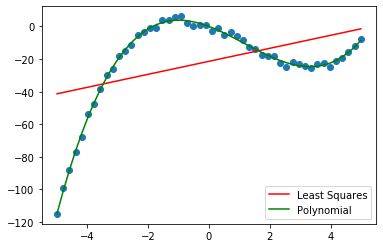

Least Squares: MSE=566.817, R^2=0.195
   Polynomial: MSE=2.017, R^2=0.997
Polynomial is better!


In [3]:
m, b = lstsq(x, y)
_, y_pred = polyfit(x, y, 3)

plt.scatter(x, y)
plt.plot(x, m*x + b, 'r-', label="Least Squares")
plt.plot(x, y_pred, 'g-', label="Polynomial")
plt.legend()
plt.show()

choose_a_method(x, y, m, b, y_pred, np.mean(y))

### Part B

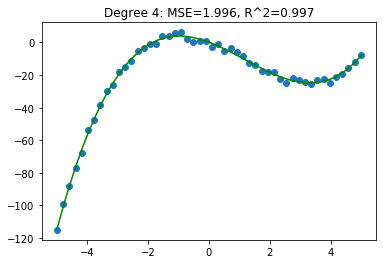

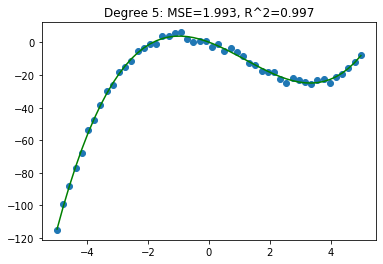

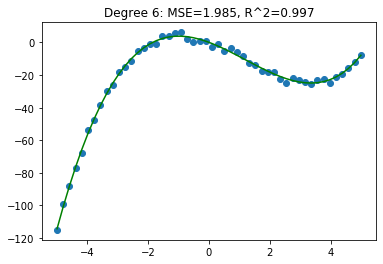

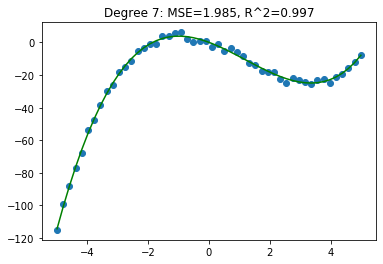

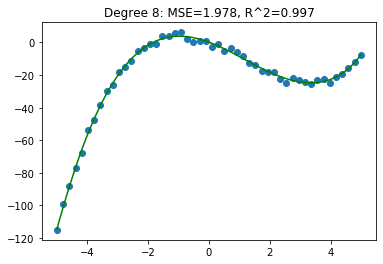

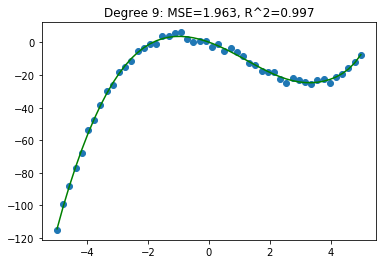

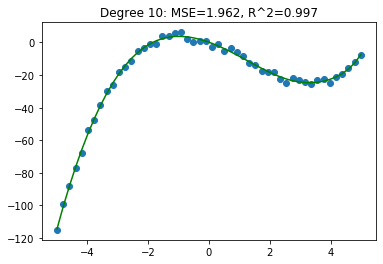

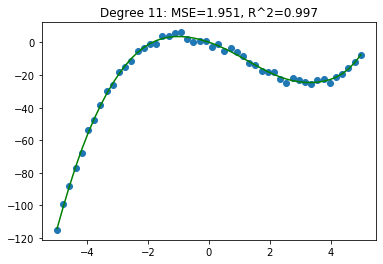

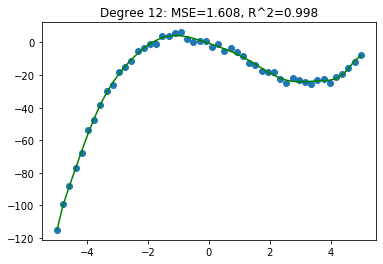

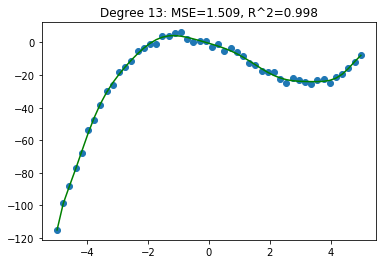

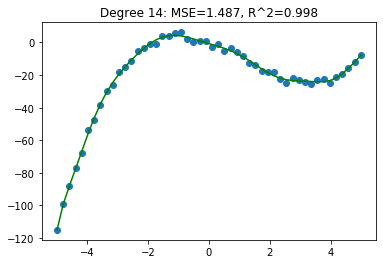

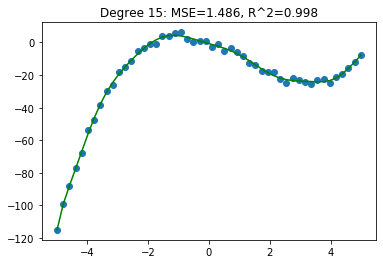

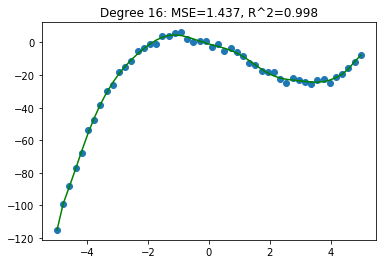

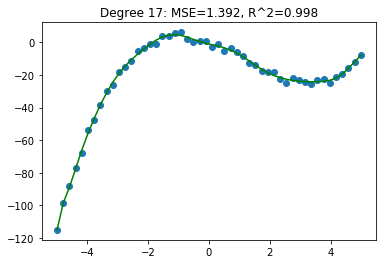

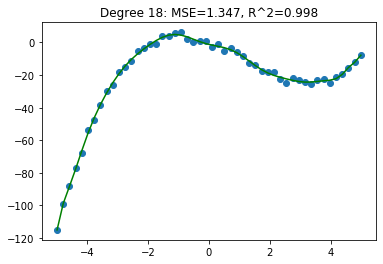

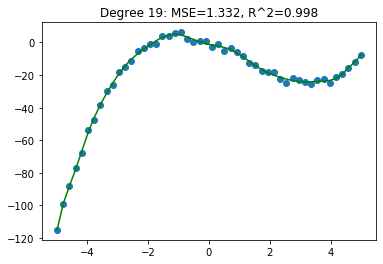

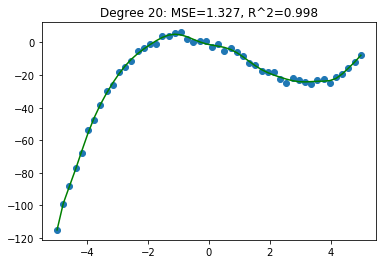

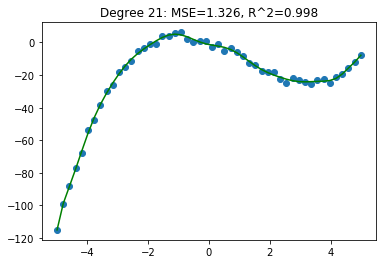

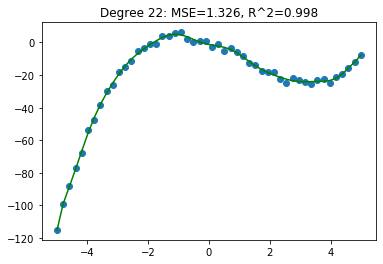

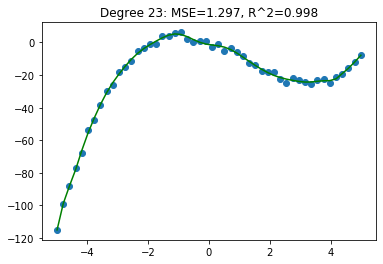

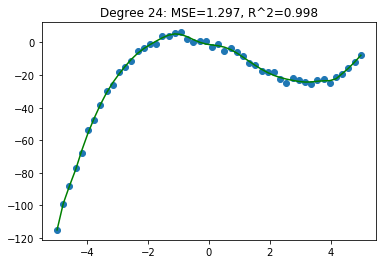

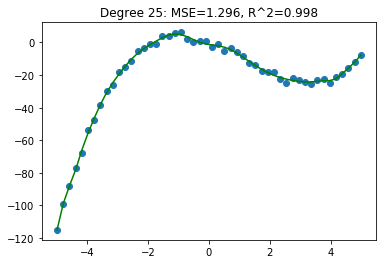

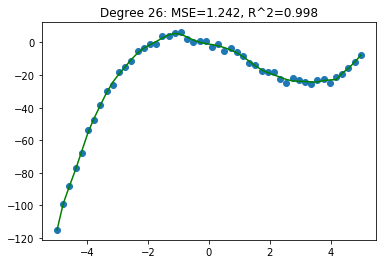

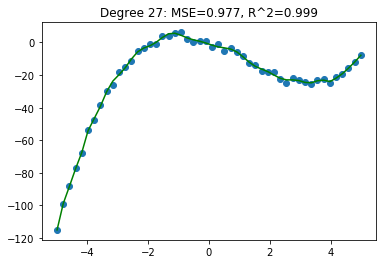

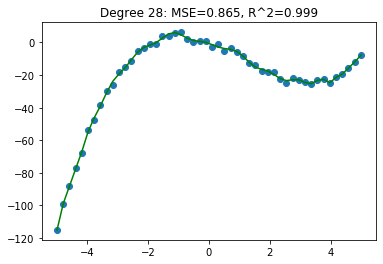

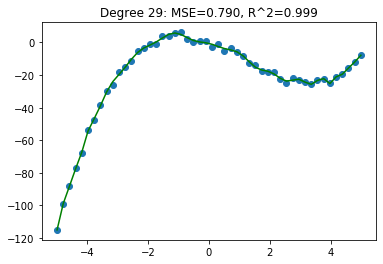

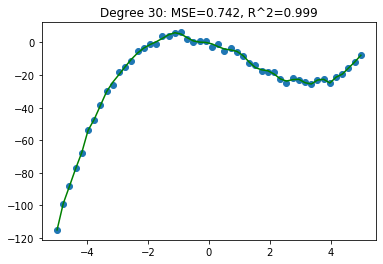

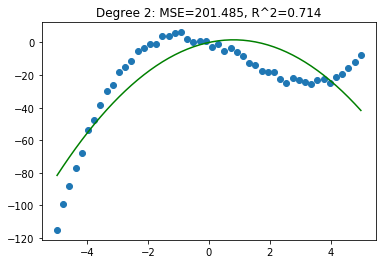

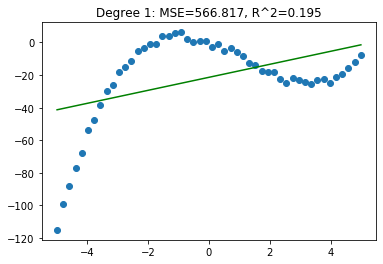

In [4]:
# Overfitting
for degree in range(4,30+1):
    _, y_pred = polyfit(x, y, degree)
    this_mse = mse(y, y_pred)
    this_rsq = rsq(y, np.mean(y), y_pred)
    plt.scatter(x,y)
    plt.plot(x, y_pred, 'g-')
    plt.title(f"Degree {degree}: MSE={this_mse:.3f}, R^2={this_rsq:.3f}")
    plt.show()
    
# Underfitting
for degree in [2,1]:
    _, y_pred = polyfit(x, y, degree)
    this_mse = mse(y, y_pred)
    this_rsq = rsq(y, np.mean(y), y_pred)
    plt.scatter(x,y)
    plt.plot(x, y_pred, 'g-')
    plt.title(f"Degree {degree}: MSE={this_mse:.3f}, R^2={this_rsq:.3f}")
    plt.show()

### Part C

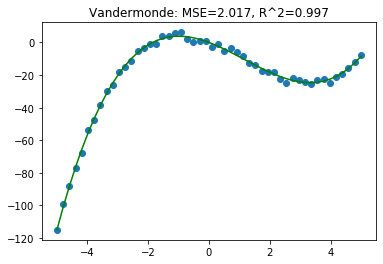

In [5]:
V = np.vander(x, N=4, increasing=True)
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)
coefficients = np.linalg.solve(VT_V, VT_y)
y_pred = (np.poly1d(coefficients[::-1]))(x)
this_mse = mse(y, y_pred)
this_rsq = rsq(y, np.mean(y), y_pred)

plt.scatter(x, y)
plt.plot(x, y_pred, 'g-')
plt.title(f"Vandermonde: MSE={this_mse:.3f}, R^2={this_rsq:.3f}")
plt.show()